# Проверка гипотезы: сравнение групп (наблюдательные данные)
## Brazilian E-Commerce Public Dataset by Olist

Продуктовый анализ маркетплейса Olist: ключевые метрики, помесячная выручка, попытка когортного анализа и **наблюдательное сравнение групп** по типу оплаты.

> **Важно.** Это НЕ A/B-тест. Группы (кредитная карта / ваучер) не формировались случайным сплитом — клиенты сами выбирали способ оплаты. Поэтому любые различия могут объясняться конфаундерами (тип товара, сумма заказа, сегмент клиента), а не самим способом оплаты. Настоящие рандомизированные A/B-тесты — в Project_3.

### 1. Импорт библиотек, загрузка и проверка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

print(orders.shape)
print(orders.dtypes)

(99441, 8)
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [2]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(orders['order_status'].value_counts())

print('\nПериод данных:')
print(f"С: {orders['order_purchase_timestamp'].min()}")
print(f"По: {orders['order_purchase_timestamp'].max()}")

print('\nПропуски:')
print(orders.isnull().sum())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Период данных:
С: 2016-09-04 21:15:19
По: 2018-10-17 17:30:18

Пропуски:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


### 2. Объединяем заказы с платежами и считаем ARPPU

Берём только доставленные заказы (`delivered`) и присоединяем платежи. ARPPU = суммарная выручка / число уникальных покупателей.

In [3]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

df = pd.merge(orders_delivered, payments, on='order_id', how='left')

arppu = df['payment_value'].sum() / df['customer_id'].nunique()
print(f"Всего выручка: {df['payment_value'].sum():,.0f} BRL")
print(f"Уникальных покупателей: {df['customer_id'].nunique():,}")
print(f"ARPPU: {arppu:.2f} BRL")

Всего выручка: 15,422,462 BRL
Уникальных покупателей: 96,478
ARPPU: 159.85 BRL


### 3. Помесячная агрегация выручки

Считаем месяц покупки и агрегируем выручку, число заказов и покупателей по месяцам.

In [4]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
delivered_grouped_df = df.groupby('month').agg(
    payment_value_agg=('payment_value', 'sum'),
    order_id_agg=('order_id', 'nunique'),
    customer_id_agg=('customer_id', 'nunique')).reset_index()
delivered_grouped_df.tail(15)

,month,payment_value_agg,order_id_agg,customer_id_agg
8,2017-06,490225.60,3135,3135
9,2017-07,566403.93,3872,3872
10,2017-08,646000.61,4193,4193
11,2017-09,701169.99,4150,4150
12,2017-10,751140.27,4478,4478
13,2017-11,1153528.05,7289,7289
14,2017-12,843199.17,5513,5513
15,2018-01,1078606.86,7069,7069
16,2018-02,966510.88,6555,6555
17,2018-03,1120678.00,7003,7003


### 4. График выручки по месяцам

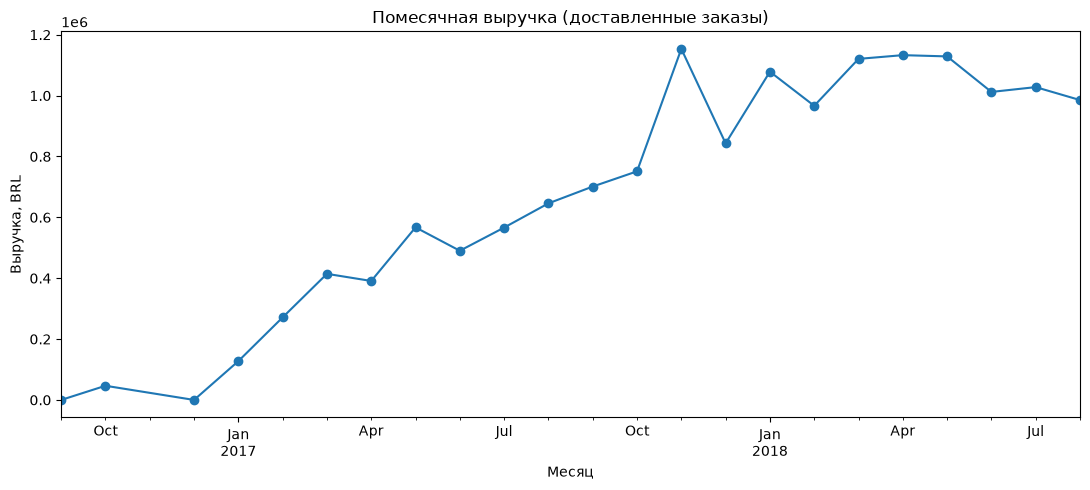

In [5]:
ax = delivered_grouped_df.plot(kind='line', x='month', y='payment_value_agg',
                               figsize=(11, 5), marker='o', legend=False)
ax.set_title('Помесячная выручка (доставленные заказы)')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка, BRL')
plt.tight_layout()
plt.show()

### 5. Попытка когортного анализа Retention

Строим когорты по месяцу первой покупки и матрицу удержания.

In [6]:
df_cohort = df.groupby('customer_id').agg(cohort_month=('month', 'min'))
df = pd.merge(df, df_cohort, on='customer_id', how='left')
df['cohort_index'] = ((df['month'].dt.year - df['cohort_month'].dt.year) * 12
                      + (df['month'].dt.month - df['cohort_month'].dt.month))

pivot = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().unstack()
retention = pivot.divide(pivot[0], axis=0) * 100
print(retention.iloc[:10, :6])

cohort_index      0
cohort_month       
2016-09       100.0
2016-10       100.0
2016-12       100.0
2017-01       100.0
2017-02       100.0
2017-03       100.0
2017-04       100.0
2017-05       100.0
2017-06       100.0
2017-07       100.0


В матрице заполнен только столбец `cohort_index = 0` (100%). Это значит, что **повторных покупок практически нет** — каждый `customer_id` уникален для одного заказа (особенность датасета Olist, где идентификатор покупателя привязан к заказу). Полноценный Retention на этих данных построить нельзя.

### 6. Сравнение групп по типу оплаты (наблюдательные данные)

**Вопрос:** отличается ли средний размер платежа для оплаты кредитной картой и ваучером?

- **H0:** средние размеры платежа в двух группах равны.
- **H1:** средние различаются.

Ещё раз подчеркнём: это **наблюдательное сравнение**, а не A/B-тест — распределение клиентов по способам оплаты не случайно.

In [7]:
group_credit = payments[payments['payment_type'] == 'credit_card']['payment_value']
group_voucher = payments[payments['payment_type'] == 'voucher']['payment_value']

print('Кредитная карта: n =', group_credit.shape[0], '| среднее =', f'{group_credit.mean():.2f}')
print('Ваучер:          n =', group_voucher.shape[0], '| среднее =', f'{group_voucher.mean():.2f}')

Кредитная карта: n = 76795 | среднее = 163.32
Ваучер:          n = 5775 | среднее = 65.70


Дисперсии и размеры групп сильно различаются, поэтому используем **Welch t-тест** (не требует равенства дисперсий) и дополняем его непараметрическим тестом **Манна-Уитни** (сравнивает распределения, устойчив к выбросам).

In [8]:
# Welch t-тест (equal_var=False)
t_stat, p_welch = stats.ttest_ind(group_credit, group_voucher, equal_var=False)
print(f'Welch t-тест:     t = {t_stat:.2f}, p-value = {p_welch:.2e}')

# Непараметрический тест Манна-Уитни
u_stat, p_mwu = stats.mannwhitneyu(group_credit, group_voucher, alternative='two-sided')
print(f'Манна-Уитни:      U = {u_stat:.0f}, p-value = {p_mwu:.2e}')

Welch t-тест:     t = 56.80, p-value = 0.00e+00
Манна-Уитни:      U = 348204386, p-value = 0.00e+00


Размер эффекта — **Cohen's d** и разница средних с 95% доверительным интервалом (через Welch-стандартную ошибку разницы).

In [9]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(group_credit, group_voucher)
diff = group_credit.mean() - group_voucher.mean()
se = np.sqrt(group_credit.var(ddof=1)/len(group_credit) + group_voucher.var(ddof=1)/len(group_voucher))
ci_low, ci_high = diff - 1.96 * se, diff + 1.96 * se

print(f"Разница средних (кредитка - ваучер): {diff:.2f} BRL")
print(f"95% ДИ разницы: [{ci_low:.2f}; {ci_high:.2f}] BRL")
print(f"Cohen's d: {d:.3f}")

Разница средних (кредитка - ваучер): 97.62 BRL
95% ДИ разницы: [94.25; 100.98] BRL
Cohen's d: 0.451


### Выводы

1. **Retention построить нельзя:** в датасете Olist каждый покупатель делает ровно один заказ (заполнен только столбец когорты 0), поэтому полноценный когортный анализ удержания невозможен.
2. **Сезонность:** пик выручки в ноябре 2017 соответствует Black Friday. ARPPU ≈ 159.85 BRL.
3. **Сравнение групп по оплате:** средний платёж по кредитной карте (~163 BRL) существенно выше, чем по ваучеру (~66 BRL). Различие статистически значимо (Welch и Манна-Уитни: p ≈ 0) и **практически значимо** — Cohen's d ≈ 0.45 (средний размер эффекта), разница ~98 BRL с узким 95% ДИ.
4. **Ограничение (важно!):** это **наблюдательное сравнение без рандомизации**. Ваучеры часто используют для частичной оплаты или мелких покупок, поэтому меньший чек может быть следствием сценария использования, а не самого способа оплаты (конфаундер). Причинный вывод на этих данных делать нельзя.
5. **О больших выборках:** при n в десятки тысяч p-value почти всегда мал, поэтому статзначимость сама по себе мало о чём говорит — ориентироваться нужно на **размер эффекта** и практическую значимость.